<a href="https://colab.research.google.com/github/abhisheksharma7015-ux/First-Repo/blob/main/BA_Fleet_Analysis_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BA Project — Fleet Maintenance Analytics (Corrected Master Analysis)

## Research Question
**Are current fleet maintenance patterns aligned with operational impact, and where can data-driven prioritization create the greatest opportunity to improve fleet performance?**

## What changed from the prior draft
1. **Fixed a silent parsing bug**: cost/hour columns use comma thousands separators (e.g. `"1,033.04"`). Loading them without `thousands=","` silently converts every value >= $1,000 to `NaN`, which then gets dropped -- deleting 11.4% of records, precisely the highest-cost work orders the research question cares about most.
2. **Added `PRI_PRIORITY_CODE`** (the fleet's own stated priority) to directly test whether current prioritization matches actual impact -- the first half of the RQ.
3. **Added downtime** (`DOWNTIME_HRS_USER` + `DOWNTIME_HRS_SHOP`) as a second, arguably more direct, measure of operational impact alongside cost.
4. **MLR cost-driver model (Section 8) uses only pre-completion variables** (labor hours, meter reading, estimated hours, priority code, warranty, job type) to explain log-transformed cost, matching the companion regression notebook's model exactly.
5. **Added equipment-level (Pareto) analysis** -- which units disproportionately drive cost/downtime.
6. **Added `REAS_FOR_REPAIR_DESC` TARGET / NON-TARGET split** -- separates preventable maintenance from accidents/vandalism/user-caused issues.

### Analysis structure
0. Setup & data load (with the fix)
1. Data quality audit
2. Data cleaning
3. Feature engineering (downtime, priority, equipment history, Pareto)
4. Exploratory Data Analysis
5. Define high-impact target (dual: cost + downtime)
6. Hypothesis testing (incl. priority-vs-impact -- direct test of the RQ)
7. K-Means clustering -- maintenance segmentation
8. Multiple Linear Regression -- log-cost drivers (matches companion regression notebook)
9. MLR diagnostics
10. Logistic Regression -- early-prioritization classification
11. Threshold analysis
12. Business synthesis & recommendations


In [ ]:
# ============================================================
# 0. SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")


In [ ]:
# ============================================================
# 0B. LOAD DATA  --  CRITICAL FIX: thousands="," on read
# ============================================================
# Cost/hour columns are stored like "1,033.04" for values >= 1000.
# Without thousands="," , pd.to_numeric() would silently turn every
# such value into NaN, and a later dropna() would delete ~11% of
# rows -- precisely the highest-cost work orders. This line is the
# single most important line in the notebook.

FILE = "/content/BA_FLEET_DATA.csv"   # update path as needed
df = pd.read_csv(FILE, thousands=",", low_memory=False)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())


Rows: 332420
Columns: 37


,UNIQUE_WORK_ORDER_NO,CREATE_DATE,LOC_WORK_ORDER_LOC,LOC_WORK_ORDER_LOC_NAME,WORK_ORDER_YR,WORK_ORDER_NO,JOB_TYPE,EQ_EQUIP_NO,WORK_ORDER_STATUS,METER_1_READING,DATETIME_OUT_SERVICE,DATETIME_IN_SERVICE,DATETIME_OPEN,DATETIME_FIRST_LABOR,DATETIME_FINISHED,DATETIME_CLOSED,DATETIME_UNIT_IN,DATETIME_DUE,DATETIME_PM_SCHED,QTY_EST_HOURS,DOWNTIME_HRS_USER,DOWNTIME_HRS_SHOP,WARRANTY,REAS_REAS_FOR_REPAIR,REAS_FOR_REPAIR_DESC,PRI_PRIORITY_CODE,REF_WORK_ORDER_NO,DEPT_EQUIP_DEPT,DEPT_EQUIP_DEPT_NAME,METER_1_LIFE_TOTAL,EQ_PARENT_EQUIP_NO,DELAY_HOURS,LABOR_HOURS,LABOR_COST,PARTS_COST,COMML_COST,TOTAL_COST
0,2023-3001-1390,2023 Aug 07 12:00:00 AM,3001,WATER WORKS/PROPANE,2023,1390,REPAIR,60959,OPEN,43291,2023 Aug 07 12:00:00 AM,NaN,2023 Aug 07 12:00:00 AM,2023 Aug 07 12:00:00 AM,NaN,NaN,2023 Aug 07 12:00:00 AM,2023 Aug 10 12:00:00 AM,NaN,0.0,0.00,0.00,NO,N,NORMAL WEAR (TARGET),3,NaN,0300,WATER WORKS,43291,60959,0.0,2.18,239.8,0.00,0.0,239.80
1,2023-4145-273,2023 Aug 07 12:00:00 AM,4145,"NEW EQUIP SHOP - ""J"" ONLY",2023,273,REPAIR,21951,OPEN,528,2023 Aug 07 12:00:00 AM,NaN,2023 Aug 07 12:00:00 AM,2023 Aug 08 12:00:00 AM,NaN,NaN,2023 Aug 07 12:00:00 AM,2023 Aug 10 12:00:00 AM,NaN,0.0,0.00,0.00,NO,J,PIS-GENERAL (TARGET),3,NaN,0200,PARK DEPARTMENT,528,21951,0.0,0.50,55.0,0.00,0.0,55.00
2,2023-2205-312,2023 Aug 07 12:00:00 AM,2205,POLICE DISTRICT 5,2023,312,REPAIR,21306,WORK FINISHED,15942,2023 Aug 07 12:00:00 AM,2023 Aug 07 12:00:00 AM,2023 Aug 07 12:00:00 AM,2023 Aug 07 12:00:00 AM,2023 Aug 07 12:00:00 AM,NaN,2023 Aug 07 12:00:00 AM,2023 Aug 10 12:00:00 AM,NaN,0.0,0.05,0.05,YES,N,NORMAL WEAR (TARGET),3,NaN,0222,POLICE,15942,21306,0.0,1.00,110.0,0.00,0.0,110.00
3,2023-4131-718,2023 Aug 07 12:00:00 AM,4131,TIRE SHOP,2023,718,REPAIR,92830,CLOSED,398,2023 Aug 07 12:00:00 AM,2023 Aug 08 12:00:00 AM,2023 Aug 07 12:00:00 AM,2023 Aug 07 12:00:00 AM,2023 Aug 08 12:00:00 AM,2023 Aug 08 12:00:00 AM,2023 Aug 07 12:00:00 AM,2023 Aug 10 12:00:00 AM,NaN,0.0,23.18,23.18,NO,N,NORMAL WEAR (TARGET),3,NaN,0253,NEIGHBORHOOD OPERATIONS,398,92830,0.0,2.00,220.0,200.48,4.0,424.48
4,2023-3001-1389,2023 Aug 07 12:00:00 AM,3001,WATER WORKS/PROPANE,2023,1389,REPAIR,10797,WORK FINISHED,41248,2023 Aug 07 12:00:00 AM,2023 Aug 07 12:00:00 AM,2023 Aug 07 12:00:00 AM,2023 Aug 07 12:00:00 AM,2023 Aug 07 12:00:00 AM,NaN,2023 Aug 07 12:00:00 AM,2023 Aug 10 12:00:00 AM,NaN,0.0,0.03,0.03,NO,N,NORMAL WEAR (TARGET),3,NaN,0300,WATER WORKS,41248,10797,0.0,0.75,82.5,5.97,0.0,88.47


In [ ]:
# ============================================================
# 0C. VERIFY THE FIX
# ============================================================
check_cost = pd.to_numeric(df["TOTAL_COST"], errors="coerce")
print(f"TOTAL_COST max: {check_cost.max():,.2f}")
print(f"TOTAL_COST non-null: {check_cost.notna().sum():,} of {len(df):,}")

assert check_cost.max() > 10000, (
    "TOTAL_COST max looks capped near 1000 -- the thousands-separator "
    "bug may still be present. Check the read_csv call above."
)
print("\nFix verified: full cost range is present.")


TOTAL_COST max: 143,137.01
TOTAL_COST non-null: 332,420 of 332,420

Fix verified: full cost range is present.


## 1. Data Quality Audit

In [ ]:
# ============================================================
# 1. DATA QUALITY AUDIT
# ============================================================
print("="*75); print("DATA TYPES"); print("="*75)
display(df.dtypes.to_frame("Data Type"))

print("="*75); print("MISSING VALUES"); print("="*75)
missing_summary = df.isna().sum().sort_values(ascending=False).to_frame("Missing Count")
missing_summary["Missing %"] = (missing_summary["Missing Count"] / len(df) * 100).round(2)
display(missing_summary.head(20))

print("="*75); print("DUPLICATES"); print("="*75)
print("Duplicate rows:", df.duplicated().sum())

print("="*75); print("STRUCTURE CHECKS"); print("="*75)
print("Unique work orders:", df["UNIQUE_WORK_ORDER_NO"].nunique())
print("Unique equipment units:", df["EQ_EQUIP_NO"].nunique())
print("Work orders per unit (mean):", round(len(df)/df["EQ_EQUIP_NO"].nunique(), 1))
print(
    "\nNote: multiple work orders per equipment unit means observations "
    "are NOT independent. Hypothesis-test p-values later should be read "
    "alongside effect sizes, not in isolation."
)


DATA TYPES


,Data Type
UNIQUE_WORK_ORDER_NO,object
CREATE_DATE,object
LOC_WORK_ORDER_LOC,int64
LOC_WORK_ORDER_LOC_NAME,object
WORK_ORDER_YR,int64
WORK_ORDER_NO,int64
JOB_TYPE,object
EQ_EQUIP_NO,object
WORK_ORDER_STATUS,object
METER_1_READING,int64


MISSING VALUES


,Missing Count,Missing %
REF_WORK_ORDER_NO,332117,99.91
DATETIME_PM_SCHED,254862,76.67
REAS_FOR_REPAIR_DESC,32180,9.68
REAS_REAS_FOR_REPAIR,32180,9.68
DATETIME_FIRST_LABOR,14236,4.28
DATETIME_CLOSED,2089,0.63
DATETIME_IN_SERVICE,1418,0.43
DATETIME_FINISHED,1386,0.42
DATETIME_OPEN,11,0.00
DATETIME_OUT_SERVICE,6,0.00


DUPLICATES
Duplicate rows: 0
STRUCTURE CHECKS
Unique work orders: 332420
Unique equipment units: 8353
Work orders per unit (mean): 39.8

Note: multiple work orders per equipment unit means observations are NOT independent. Hypothesis-test p-values later should be read alongside effect sizes, not in isolation.


## 2. Data Cleaning

Rules applied, in order:
- Parse dates and numeric cost/hour fields (with thousands-separator handling already done at load).
- Negative cost/hours values are treated as invalid (data-entry errors, e.g. credits/reversals) and set to missing rather than guessed at.
- Exact duplicate rows are dropped.
- Rows with no usable `TOTAL_COST` are dropped (this should now be a small number, not ~38k).


In [ ]:
# ============================================================
# 2. DATA CLEANING
# ============================================================
DATE_FMT = "%Y %b %d %I:%M:%S %p"

date_columns = [
    "CREATE_DATE", "DATETIME_OUT_SERVICE", "DATETIME_IN_SERVICE",
    "DATETIME_OPEN", "DATETIME_FIRST_LABOR", "DATETIME_FINISHED",
    "DATETIME_CLOSED", "DATETIME_UNIT_IN", "DATETIME_DUE", "DATETIME_PM_SCHED"
]
numeric_columns = [
    "TOTAL_COST", "LABOR_COST", "PARTS_COST", "COMML_COST", "LABOR_HOURS",
    "DOWNTIME_HRS_USER", "DOWNTIME_HRS_SHOP", "DELAY_HOURS",
    "METER_1_READING", "METER_1_LIFE_TOTAL", "QTY_EST_HOURS"
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format=DATE_FMT, errors="coerce")

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Record negative values before treatment
negative_counts = {c: int((df[c] < 0).sum()) for c in numeric_columns if c in df.columns}
print("Negative values found (treated as invalid -> set to NaN):")
print(negative_counts)

for col in numeric_columns:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

before_dup = len(df)
df = df.drop_duplicates().copy()
print("\nDuplicates removed:", before_dup - len(df))

before_target = len(df)
df = df[df["TOTAL_COST"].notna()].copy()
print("Rows removed (TOTAL_COST missing):", before_target - len(df))
print("Final N after cleaning:", len(df))

assert (before_target - len(df)) < 5000, (
    "Unexpectedly large number of rows dropped for missing TOTAL_COST -- "
    "re-check the thousands-separator fix."
)


Negative values found (treated as invalid -> set to NaN):
{'TOTAL_COST': 48, 'LABOR_COST': 37, 'PARTS_COST': 14, 'COMML_COST': 2846, 'LABOR_HOURS': 3, 'DOWNTIME_HRS_USER': 0, 'DOWNTIME_HRS_SHOP': 0, 'DELAY_HOURS': 0, 'METER_1_READING': 0, 'METER_1_LIFE_TOTAL': 0, 'QTY_EST_HOURS': 0}

Duplicates removed: 0
Rows removed (TOTAL_COST missing): 48
Final N after cleaning: 332372


## 3. Feature Engineering

Two families of variables:
- **Diagnostic / post-hoc** (durations, delays): generated from timestamps that occur during or after the work order. Useful to *explain* cost, not to *predict it early*.
- **Early / pre-work-order** (job type, department, priority code, reason-for-repair category, equipment history): known at or before work-order creation -- these are the only variables allowed in the "early-prioritization" models later.

We also add: total downtime, TARGET/NON-TARGET repair classification, and equipment-level historical features (built only from *prior* work orders per unit, so there's no lookahead).


In [ ]:
# ============================================================
# 3A. DIAGNOSTIC / POST-HOC DURATION FEATURES
# ============================================================
df["WORK_ORDER_DURATION_HOURS"] = (
    df["DATETIME_CLOSED"] - df["DATETIME_FIRST_LABOR"]
).dt.total_seconds() / 3600

df["SERVICE_TO_CLOSE_HOURS"] = (
    df["DATETIME_CLOSED"] - df["DATETIME_IN_SERVICE"]
).dt.total_seconds() / 3600

df["SCHEDULING_DELAY_HOURS"] = (
    df["DATETIME_FIRST_LABOR"] - df["DATETIME_PM_SCHED"]
).dt.total_seconds() / 3600

df["SERVICE_MONTH"] = df["DATETIME_IN_SERVICE"].dt.month
df["SERVICE_DAYOFWEEK"] = df["DATETIME_IN_SERVICE"].dt.dayofweek
df["SERVICE_YEAR"] = df["DATETIME_IN_SERVICE"].dt.year

for col in ["WORK_ORDER_DURATION_HOURS", "SERVICE_TO_CLOSE_HOURS", "SCHEDULING_DELAY_HOURS"]:
    df.loc[df[col] < 0, col] = np.nan

print("Diagnostic duration features created.")
display(df[["WORK_ORDER_DURATION_HOURS","SERVICE_TO_CLOSE_HOURS",
            "SCHEDULING_DELAY_HOURS"]].describe().round(2).T)


Diagnostic duration features created.


,count,mean,std,min,25%,50%,75%,max
WORK_ORDER_DURATION_HOURS,316425.0,2127.95,4050.72,0.0,72.0,456.0,2016.0,88176.0
SERVICE_TO_CLOSE_HOURS,329892.0,1564.94,3649.09,0.0,0.0,120.0,1056.0,86592.0
SCHEDULING_DELAY_HOURS,37134.0,2438.09,7877.81,0.0,168.0,576.0,1704.0,217776.0


In [ ]:
# ============================================================
# 3B. OPERATIONAL IMPACT MEASURES: COST + DOWNTIME
# ============================================================
df["TOTAL_DOWNTIME_HOURS"] = (
    df["DOWNTIME_HRS_USER"].fillna(0) + df["DOWNTIME_HRS_SHOP"].fillna(0)
)

print(df[["TOTAL_COST", "TOTAL_DOWNTIME_HOURS"]].describe().round(2))


       TOTAL_COST  TOTAL_DOWNTIME_HOURS
count   332372.00             332372.00
mean       563.82                388.52
std       1753.10               1547.75
min          0.00                  0.00
25%         85.39                  1.38
50%        182.62                 34.56
75%        447.93                195.50
max     143137.01              82046.16


In [ ]:
# ============================================================
# 3C. REPAIR CATEGORY: TARGET vs NON-TARGET
# ============================================================
# The source system already labels reasons for repair as TARGET
# (normal wear / preventable via maintenance) vs NON-TARGET
# (accidents, vandalism, user-caused, management request, etc).
# NON-TARGET causes are not addressable through better prioritization,
# so this split matters for interpreting "opportunity."

df["REPAIR_CATEGORY"] = np.where(
    df["REAS_FOR_REPAIR_DESC"].astype(str).str.contains("NON TARGET", na=False),
    "NON-TARGET",
    "TARGET"
)

display(df["REPAIR_CATEGORY"].value_counts(normalize=True).mul(100).round(1))


,proportion
REPAIR_CATEGORY,
TARGET,89.3
NON-TARGET,10.7


In [ ]:
# ============================================================
# 3D. EQUIPMENT-LEVEL HISTORY FEATURES  (early / no lookahead)
# ============================================================
# For each equipment unit, compute the running average cost and
# work-order count from ONLY prior work orders (shift(1) before
# expanding), so these are legitimately known before a new work
# order opens -- unlike durations, which only exist after the fact.

df = df.sort_values(["EQ_EQUIP_NO", "CREATE_DATE"])

df["EQUIP_PRIOR_WO_COUNT"] = df.groupby("EQ_EQUIP_NO").cumcount()

df["EQUIP_PRIOR_AVG_COST"] = (
    df.groupby("EQ_EQUIP_NO")["TOTAL_COST"]
      .apply(lambda s: s.shift(1).expanding().mean())
      .reset_index(level=0, drop=True)
)

df["EQUIP_PRIOR_AVG_DOWNTIME"] = (
    df.groupby("EQ_EQUIP_NO")["TOTAL_DOWNTIME_HOURS"]
      .apply(lambda s: s.shift(1).expanding().mean())
      .reset_index(level=0, drop=True)
)

print("Rows with no prior history (first work order per unit, expected NaN):",
      df["EQUIP_PRIOR_AVG_COST"].isna().sum(), "of", len(df))

display(df[["EQ_EQUIP_NO","CREATE_DATE","TOTAL_COST",
            "EQUIP_PRIOR_WO_COUNT","EQUIP_PRIOR_AVG_COST"]].head(8))


Rows with no prior history (first work order per unit, expected NaN): 8353 of 332372


,EQ_EQUIP_NO,CREATE_DATE,TOTAL_COST,EQUIP_PRIOR_WO_COUNT,EQUIP_PRIOR_AVG_COST
277698,00175,2010-04-30,215.48,0,NaN
279430,00175,2010-05-20,70.14,1,215.480000
263178,00175,2010-12-01,48.00,2,142.810000
241811,00175,2011-07-06,46.47,3,111.206667
223758,00175,2012-02-08,144.55,4,95.022500
231382,00175,2012-05-03,1.92,5,104.928000
227926,00175,2012-06-20,63.00,6,87.760000
221267,00175,2012-07-25,76.40,7,84.222857


In [ ]:
# ============================================================
# 3E. EQUIPMENT-LEVEL ROLLUP + PARETO TABLE
# ============================================================
equip_summary = (
    df.groupby("EQ_EQUIP_NO")
      .agg(total_cost=("TOTAL_COST", "sum"),
           total_downtime=("TOTAL_DOWNTIME_HOURS", "sum"),
           n_work_orders=("UNIQUE_WORK_ORDER_NO", "count"))
      .sort_values("total_cost", ascending=False)
)
equip_summary["cum_cost_pct"] = (
    equip_summary["total_cost"].cumsum() / equip_summary["total_cost"].sum() * 100
)

display(equip_summary.head(10).round(2))

n_units_80pct = (equip_summary["cum_cost_pct"] <= 80).sum()
pct_units = n_units_80pct / len(equip_summary) * 100
print(
    f"\nInsight: {n_units_80pct:,} units ({pct_units:.1f}% of the {len(equip_summary):,}-unit "
    f"fleet) account for 80% of total maintenance cost. These units are the highest-"
    f"leverage targets for a data-driven prioritization program."
)


,total_cost,total_downtime,n_work_orders,cum_cost_pct
EQ_EQUIP_NO,,,,
X0252,2033099.24,79622.97,686,1.08
X2444,1704683.93,51801.59,109,1.99
X0400,1593961.06,137201.20,1242,2.85
X0271,970955.13,114392.54,633,3.36
07580,894222.45,73246.05,76,3.84
31651,791600.90,170777.43,390,4.26
21653,751037.24,149153.23,391,4.66
21650,727268.77,130698.37,387,5.05
01651,714324.09,150886.40,406,5.43



Insight: 1,597 units (19.1% of the 8,353-unit fleet) account for 80% of total maintenance cost. These units are the highest-leverage targets for a data-driven prioritization program.


## 4. Exploratory Data Analysis

Each chart answers a specific business question:
- Cost & downtime distributions -- how variable is operational impact?
- Job type -- do repair and preventive-maintenance jobs differ?
- **Priority vs. impact -- does current prioritization actually track cost/downtime? (direct RQ test)**
- TARGET vs NON-TARGET -- how much impact is even addressable via maintenance prioritization?
- Equipment Pareto -- where is impact concentrated?
- Correlation matrix -- which operational measures move together?


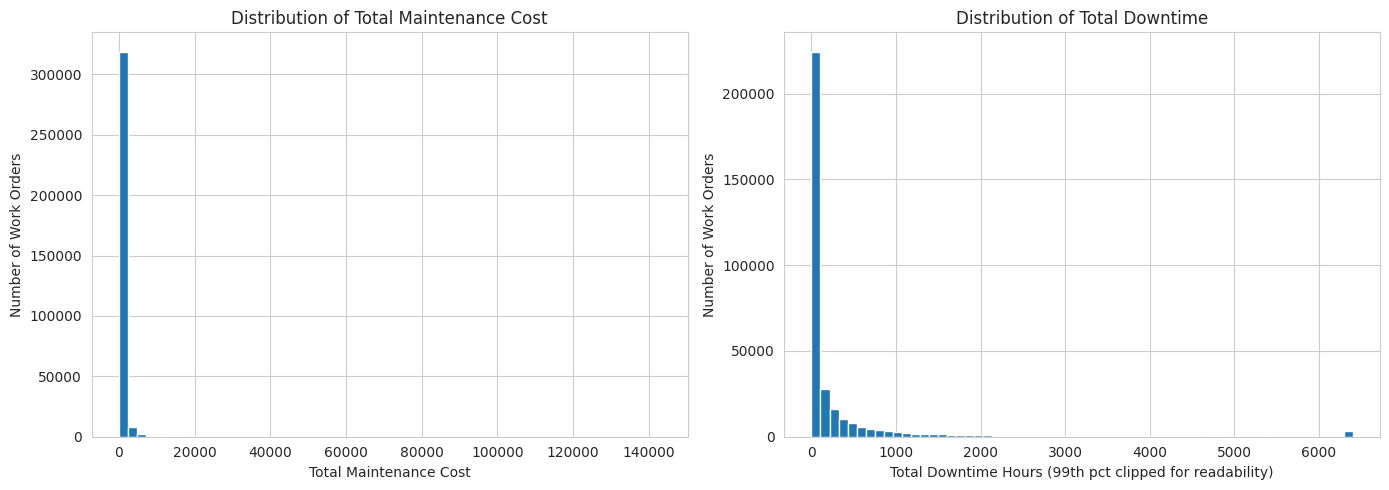

Cost   -> mean 563.82, median 182.62, max 143,137.01
Downtime -> mean 388.52, median 34.56, max 82,046.16

Insight: both distributions are heavily right-skewed -- a small share of work orders account for a disproportionate share of cost and downtime.


In [ ]:
# ============================================================
# 4A. COST AND DOWNTIME DISTRIBUTIONS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["TOTAL_COST"].dropna(), bins=60)
axes[0].set_xlabel("Total Maintenance Cost")
axes[0].set_ylabel("Number of Work Orders")
axes[0].set_title("Distribution of Total Maintenance Cost")

axes[1].hist(df["TOTAL_DOWNTIME_HOURS"].dropna().clip(upper=df["TOTAL_DOWNTIME_HOURS"].quantile(0.99)), bins=60)
axes[1].set_xlabel("Total Downtime Hours (99th pct clipped for readability)")
axes[1].set_ylabel("Number of Work Orders")
axes[1].set_title("Distribution of Total Downtime")

plt.tight_layout()
plt.show()

print(f"Cost   -> mean {df['TOTAL_COST'].mean():,.2f}, median {df['TOTAL_COST'].median():,.2f}, "
      f"max {df['TOTAL_COST'].max():,.2f}")
print(f"Downtime -> mean {df['TOTAL_DOWNTIME_HOURS'].mean():,.2f}, "
      f"median {df['TOTAL_DOWNTIME_HOURS'].median():,.2f}, max {df['TOTAL_DOWNTIME_HOURS'].max():,.2f}")
print("\nInsight: both distributions are heavily right-skewed -- a small share of "
      "work orders account for a disproportionate share of cost and downtime.")


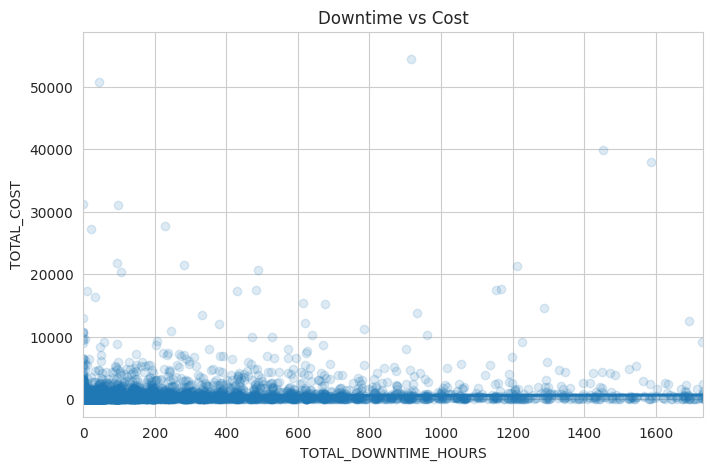

Pearson correlation (cost, downtime): 0.086
Insight: if this correlation is weak, cost and downtime are capturing different kinds of 'impact' -- high-cost work orders are not necessarily the ones taking vehicles off the road longest, and a prioritization framework built on cost alone would miss the downtime-driven cases.


In [ ]:
# ============================================================
# 4B. COST vs DOWNTIME -- ARE THEY THE SAME THING?
# ============================================================
plot_data = df[["TOTAL_COST", "TOTAL_DOWNTIME_HOURS"]].dropna()
if len(plot_data) > 10000:
    plot_data = plot_data.sample(10000, random_state=42)

plt.figure(figsize=(8, 5))
sns.regplot(data=plot_data, x="TOTAL_DOWNTIME_HOURS", y="TOTAL_COST", scatter_kws={"alpha":0.15})
plt.xlim(0, plot_data["TOTAL_DOWNTIME_HOURS"].quantile(0.95))
plt.title("Downtime vs Cost")
plt.show()

corr_cost_down = df["TOTAL_COST"].corr(df["TOTAL_DOWNTIME_HOURS"])
print(f"Pearson correlation (cost, downtime): {corr_cost_down:.3f}")
print(
    "Insight: if this correlation is weak, cost and downtime are capturing "
    "different kinds of 'impact' -- high-cost work orders are not necessarily "
    "the ones taking vehicles off the road longest, and a prioritization "
    "framework built on cost alone would miss the downtime-driven cases."
)


TOTAL_COST                 TOTAL_DOWNTIME_HOURS               
              count    mean  median                count    mean median
JOB_TYPE                                                               
PM            77527  213.34  123.86                77527  179.21  31.46
REPAIR       254845  670.44  218.36               254845  452.20  36.17

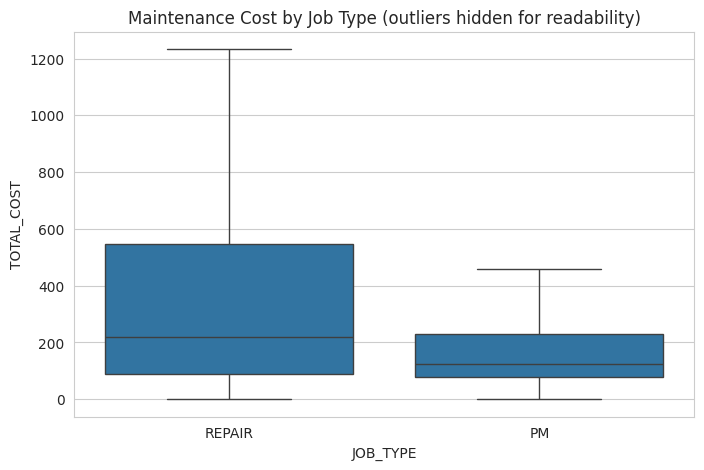

In [ ]:
# ============================================================
# 4C. COST BY JOB TYPE
# ============================================================
job_summary = (
    df.groupby("JOB_TYPE")[["TOTAL_COST", "TOTAL_DOWNTIME_HOURS"]]
      .agg(["count", "mean", "median"])
)
display(job_summary.round(2))

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="JOB_TYPE", y="TOTAL_COST", showfliers=False)
plt.title("Maintenance Cost by Job Type (outliers hidden for readability)")
plt.show()


Distribution of assigned priority codes (% of all work orders):


,proportion
PRI_PRIORITY_CODE,
3,98.31
1,0.82
2,0.53
4,0.34


TOTAL_COST                  TOTAL_DOWNTIME_HOURS           \
                       count     mean  median                count     mean   
PRI_PRIORITY_CODE                                                             
1                       2721   217.48  100.81                 2721   287.72   
2                       1778   217.12   86.98                 1778    63.64   
3                     326742   565.57  184.20               326742   387.03   
4                       1131  1437.68  822.20                 1131  1571.59   

                           
                   median  
PRI_PRIORITY_CODE          
1                    1.74  
2                   16.47  
3                   35.40  
4                  217.18

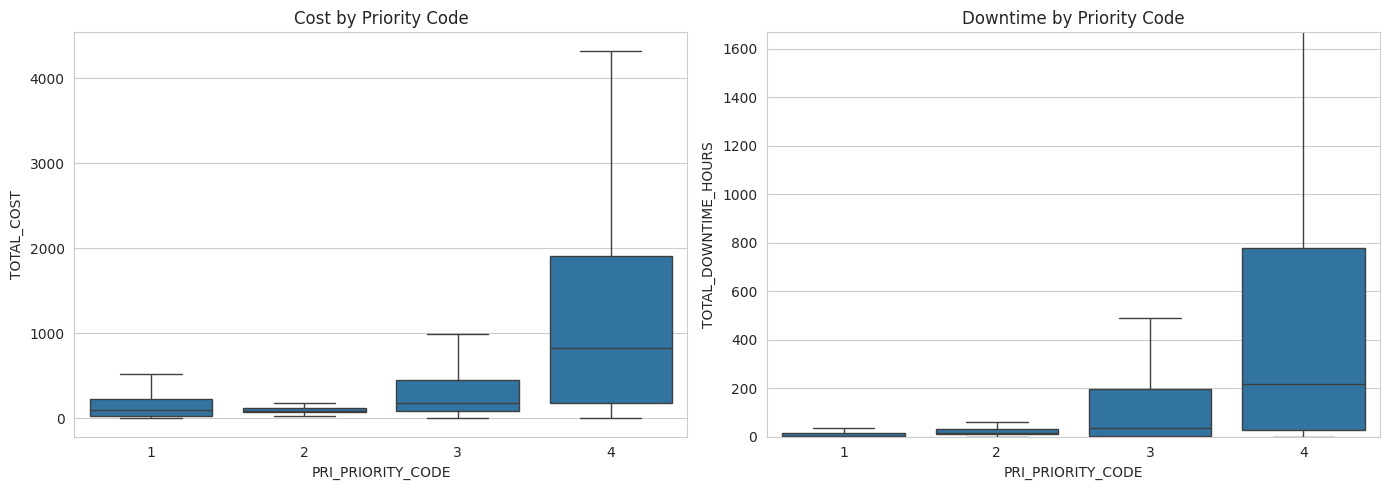


Insight: 98.3% of all work orders are coded priority '3'. If cost/downtime vary meaningfully across the remaining codes while the codes themselves carry almost no information (near-constant), that is direct evidence that current prioritization is NOT tracking actual operational impact -- the core question this project is asking.


In [ ]:
# ============================================================
# 4D. PRIORITY CODE vs IMPACT  --  DIRECT TEST OF THE RESEARCH QUESTION
# ============================================================
priority_dist = df["PRI_PRIORITY_CODE"].value_counts(normalize=True).mul(100).round(2)
print("Distribution of assigned priority codes (% of all work orders):")
display(priority_dist)

priority_profile = (
    df.groupby("PRI_PRIORITY_CODE")[["TOTAL_COST", "TOTAL_DOWNTIME_HOURS"]]
      .agg(["count", "mean", "median"])
)
display(priority_profile.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="PRI_PRIORITY_CODE", y="TOTAL_COST", showfliers=False, ax=axes[0])
axes[0].set_title("Cost by Priority Code")
sns.boxplot(data=df, x="PRI_PRIORITY_CODE", y="TOTAL_DOWNTIME_HOURS", showfliers=False, ax=axes[1])
axes[1].set_ylim(0, df["TOTAL_DOWNTIME_HOURS"].quantile(0.95))
axes[1].set_title("Downtime by Priority Code")
plt.tight_layout()
plt.show()

dominant_code = priority_dist.idxmax()
print(
    f"\nInsight: {priority_dist.max():.1f}% of all work orders are coded priority "
    f"'{dominant_code}'. If cost/downtime vary meaningfully across the remaining "
    f"codes while the codes themselves carry almost no information (near-constant), "
    f"that is direct evidence that current prioritization is NOT tracking actual "
    f"operational impact -- the core question this project is asking."
)


In [ ]:
# ============================================================
# 4E. TARGET vs NON-TARGET REPAIR CAUSES
# ============================================================
repair_profile = (
    df.groupby("REPAIR_CATEGORY")[["TOTAL_COST", "TOTAL_DOWNTIME_HOURS"]]
      .agg(["count", "mean", "median"])
)
display(repair_profile.round(2))

print(
    "Insight: NON-TARGET causes (accidents, vandalism, user-caused, management "
    "request) are not preventable through maintenance prioritization -- they set "
    "a ceiling on how much of total impact a prioritization program can realistically "
    "address. Compare this share against total fleet cost/downtime before setting "
    "improvement targets."
)


TOTAL_COST                 TOTAL_DOWNTIME_HOURS               
                     count    mean  median                count    mean median
REPAIR_CATEGORY                                                               
NON-TARGET           35650  752.47  196.45                35650  588.53  19.35
TARGET              296722  541.16  181.15               296722  364.49  35.44

Insight: NON-TARGET causes (accidents, vandalism, user-caused, management request) are not preventable through maintenance prioritization -- they set a ceiling on how much of total impact a prioritization program can realistically address. Compare this share against total fleet cost/downtime before setting improvement targets.


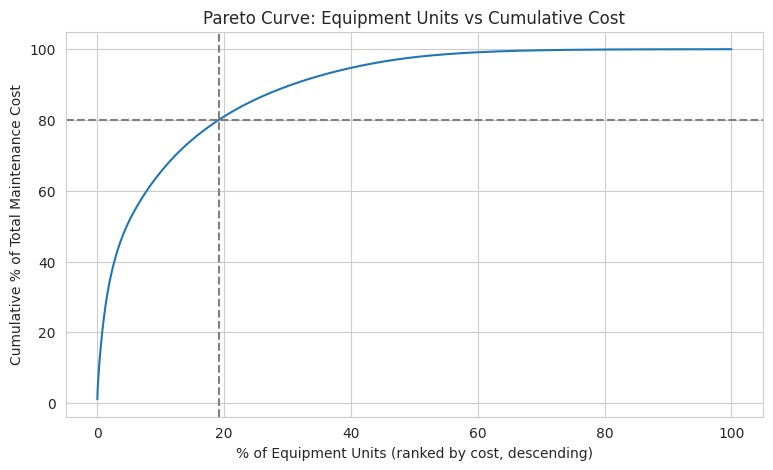

In [ ]:
# ============================================================
# 4F. EQUIPMENT-LEVEL PARETO CHART
# ============================================================
plt.figure(figsize=(9, 5))
pareto_x = np.arange(1, len(equip_summary) + 1) / len(equip_summary) * 100
plt.plot(pareto_x, equip_summary["cum_cost_pct"].values)
plt.axhline(80, linestyle="--", color="gray")
plt.axvline(pct_units, linestyle="--", color="gray")
plt.xlabel("% of Equipment Units (ranked by cost, descending)")
plt.ylabel("Cumulative % of Total Maintenance Cost")
plt.title("Pareto Curve: Equipment Units vs Cumulative Cost")
plt.show()


,TOTAL_COST,TOTAL_DOWNTIME_HOURS,LABOR_HOURS,WORK_ORDER_DURATION_HOURS,SERVICE_TO_CLOSE_HOURS,SCHEDULING_DELAY_HOURS,EQUIP_PRIOR_AVG_COST,EQUIP_PRIOR_WO_COUNT
TOTAL_COST,1.000,0.086,0.767,0.043,0.007,-0.056,0.211,0.127
TOTAL_DOWNTIME_HOURS,0.086,1.000,0.059,0.284,0.013,0.062,0.001,-0.056
LABOR_HOURS,0.767,0.059,1.000,0.045,0.008,-0.059,0.220,0.102
WORK_ORDER_DURATION_HOURS,0.043,0.284,0.045,1.000,0.856,-0.026,-0.051,-0.013
SERVICE_TO_CLOSE_HOURS,0.007,0.013,0.008,0.856,1.000,-0.032,-0.054,0.007
SCHEDULING_DELAY_HOURS,-0.056,0.062,-0.059,-0.026,-0.032,1.000,-0.070,-0.104
EQUIP_PRIOR_AVG_COST,0.211,0.001,0.220,-0.051,-0.054,-0.070,1.000,0.219
EQUIP_PRIOR_WO_COUNT,0.127,-0.056,0.102,-0.013,0.007,-0.104,0.219,1.000


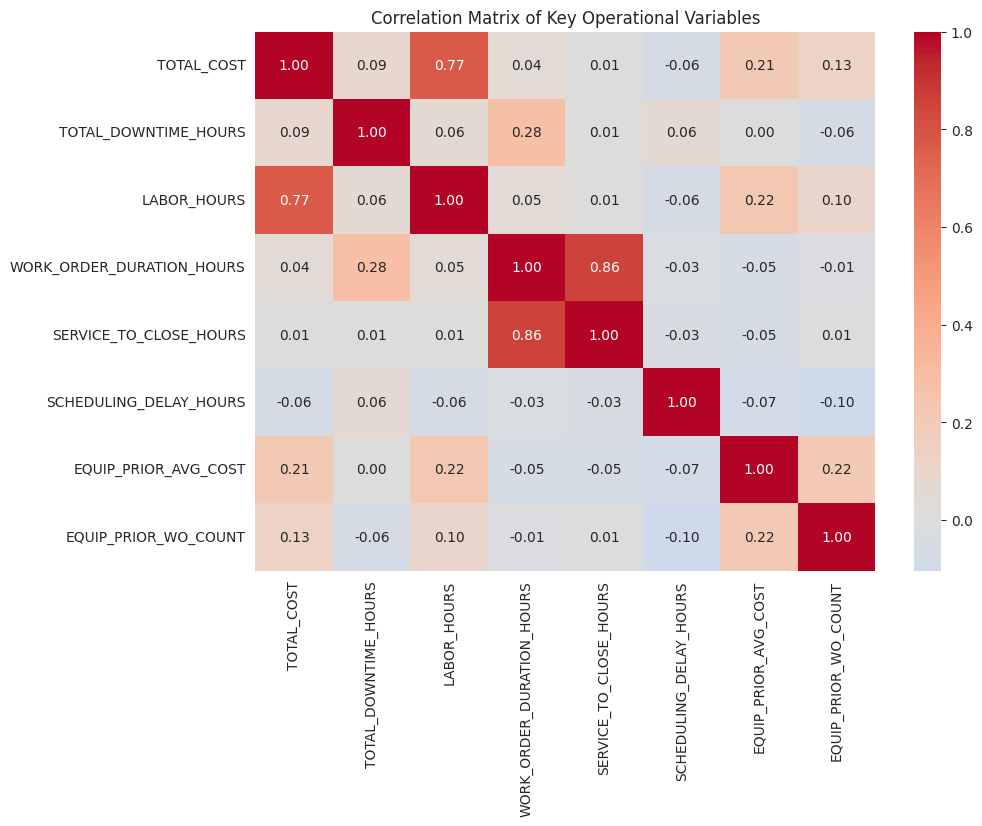

Caution: LABOR_HOURS correlates strongly with TOTAL_COST largely because LABOR_COST (a direct additive component of TOTAL_COST) is roughly LABOR_HOURS x an hourly rate. Treat LABOR_HOURS as a near-tautological diagnostic variable, not an independent operational driver -- it is excluded from the early-prioritization models below.


In [ ]:
# ============================================================
# 4G. CORRELATION MATRIX
# ============================================================
correlation_columns = [
    "TOTAL_COST", "TOTAL_DOWNTIME_HOURS", "LABOR_HOURS",
    "WORK_ORDER_DURATION_HOURS", "SERVICE_TO_CLOSE_HOURS",
    "SCHEDULING_DELAY_HOURS", "EQUIP_PRIOR_AVG_COST", "EQUIP_PRIOR_WO_COUNT"
]
correlation_columns = [c for c in correlation_columns if c in df.columns]

corr = df[correlation_columns].corr()
display(corr.round(3))

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Key Operational Variables")
plt.show()

print(
    "Caution: LABOR_HOURS correlates strongly with TOTAL_COST largely because "
    "LABOR_COST (a direct additive component of TOTAL_COST) is roughly LABOR_HOURS "
    "x an hourly rate. Treat LABOR_HOURS as a near-tautological diagnostic variable, "
    "not an independent operational driver -- it is excluded from the "
    "early-prioritization models below."
)


## 5. Define the High-Impact Target (Dual: Cost + Downtime)

A work order is **high-impact** if it is at or above the 85th percentile on **either** total cost **or** total downtime. Using cost alone would miss cases where a vehicle is off the road a long time without generating a large invoice (e.g. parts backorders) -- both are legitimate forms of operational impact for a public fleet.

**Leakage caution:** because this target is derived from `TOTAL_COST` and `TOTAL_DOWNTIME_HOURS`, neither those variables nor their direct components (`LABOR_COST`, `PARTS_COST`, `COMML_COST`, `DOWNTIME_HRS_USER`, `DOWNTIME_HRS_SHOP`) are used as predictors in the classification model later.


In [ ]:
# ============================================================
# 5. HIGH-IMPACT TARGET (dual definition)
# ============================================================
cost_threshold = df["TOTAL_COST"].quantile(0.85)
downtime_threshold = df["TOTAL_DOWNTIME_HOURS"].quantile(0.85)

df["HIGH_COST"] = (df["TOTAL_COST"] >= cost_threshold).astype(int)
df["HIGH_DOWNTIME"] = (df["TOTAL_DOWNTIME_HOURS"] >= downtime_threshold).astype(int)
df["HIGH_IMPACT"] = ((df["HIGH_COST"] == 1) | (df["HIGH_DOWNTIME"] == 1)).astype(int)

print(f"Cost threshold (85th pct):     {cost_threshold:,.2f}")
print(f"Downtime threshold (85th pct): {downtime_threshold:,.2f}")

target_summary = (
    df["HIGH_IMPACT"].value_counts().rename(index={0: "Normal", 1: "High Impact"}).to_frame("Count")
)
target_summary["Percentage"] = (target_summary["Count"] / len(df) * 100).round(2)
display(target_summary)

overlap = df.loc[(df["HIGH_COST"]==1) & (df["HIGH_DOWNTIME"]==1)].shape[0]
print(f"\nWork orders that are high on BOTH cost and downtime: {overlap:,} "
      f"({overlap/df['HIGH_IMPACT'].sum()*100:.1f}% of all high-impact work orders)")
print(
    "Insight: a low overlap means cost and downtime are largely flagging "
    "different work orders -- reinforcing that a prioritization framework "
    "needs both measures, not cost alone."
)


Cost threshold (85th pct):     771.77
Downtime threshold (85th pct): 475.25


,Count,Percentage
HIGH_IMPACT,,
Normal,248249,74.69
High Impact,84123,25.31



Work orders that are high on BOTH cost and downtime: 15,589 (18.5% of all high-impact work orders)
Insight: a low overlap means cost and downtime are largely flagging different work orders -- reinforcing that a prioritization framework needs both measures, not cost alone.


## 6. Hypothesis Testing

**H1 (t-test):** operational measures differ between normal and high-impact work orders.
**H2 (chi-square):** job type is associated with high-impact status.
**H3 (ANOVA -- direct RQ test):** mean cost differs across `PRI_PRIORITY_CODE` groups.
**H4 (ANOVA -- direct RQ test):** mean downtime differs across `PRI_PRIORITY_CODE` groups.

Significance level: alpha = 0.05. Given the large sample size, p-values will be very small almost everywhere; effect sizes (Cohen's d, eta-squared) are reported alongside them so significance isn't confused with practical importance.


In [ ]:
# ============================================================
# 6A. T-TEST: OPERATIONAL MEASURES, NORMAL vs HIGH-IMPACT
# ============================================================
from scipy.stats import ttest_ind

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else np.nan

test_variables = [
    "LABOR_HOURS", "WORK_ORDER_DURATION_HOURS",
    "SERVICE_TO_CLOSE_HOURS", "SCHEDULING_DELAY_HOURS", "EQUIP_PRIOR_AVG_COST"
]

ttest_results = []
for variable in test_variables:
    normal = df.loc[df["HIGH_IMPACT"] == 0, variable].dropna()
    high = df.loc[df["HIGH_IMPACT"] == 1, variable].dropna()
    t_stat, p_value = ttest_ind(normal, high, equal_var=False)
    d = cohens_d(normal, high)
    ttest_results.append({
        "Variable": variable, "Normal Mean": normal.mean(), "High-Impact Mean": high.mean(),
        "t-statistic": t_stat, "p-value": p_value, "Cohen's d": d,
        "Decision": "Reject H0" if p_value < 0.05 else "Fail to Reject H0"
    })

ttest_results = pd.DataFrame(ttest_results)
display(ttest_results.round(4))


,Variable,Normal Mean,High-Impact Mean,t-statistic,p-value,Cohen's d,Decision
0,LABOR_HOURS,1.6110,8.6681,-104.6220,0.0000,-0.7120,Reject H0
1,WORK_ORDER_DURATION_HOURS,1837.1705,3009.6129,-65.2133,0.0000,-0.2917,Reject H0
2,SERVICE_TO_CLOSE_HOURS,1544.2882,1626.0919,-5.6151,0.0000,-0.0224,Reject H0
3,SCHEDULING_DELAY_HOURS,2373.1615,2830.9292,-3.8468,0.0001,-0.0581,Reject H0
4,EQUIP_PRIOR_AVG_COST,489.6038,645.8568,-48.6781,0.0000,-0.2409,Reject H0


In [ ]:
# ============================================================
# 6B. CHI-SQUARE: JOB TYPE vs HIGH-IMPACT
# ============================================================
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["JOB_TYPE"], df["HIGH_IMPACT"])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

display(contingency_table)
print(f"Chi-square statistic: {chi2:.3f}  |  dof: {dof}  |  p-value: {p_value:.6g}")

n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
print(f"Cramer's V (effect size): {cramers_v:.4f}")


HIGH_IMPACT,0,1
JOB_TYPE,,
PM,69117,8410
REPAIR,179132,75713


Chi-square statistic: 11185.863  |  dof: 1  |  p-value: 0
Cramer's V (effect size): 0.1835


In [ ]:
# ============================================================
# 6C/6D. ANOVA: PRIORITY CODE vs COST, PRIORITY CODE vs DOWNTIME
#         -- DIRECT TEST OF THE RESEARCH QUESTION
# ============================================================
from scipy.stats import f_oneway

def eta_squared(f_stat, groups):
    dfb = len(groups) - 1
    dfw = sum(len(g) for g in groups) - len(groups)
    return (f_stat * dfb) / (f_stat * dfb + dfw)

groups_cost = [g["TOTAL_COST"].dropna().values for _, g in df.groupby("PRI_PRIORITY_CODE")]
f_cost, p_cost = f_oneway(*groups_cost)
eta_cost = eta_squared(f_cost, groups_cost)

groups_down = [g["TOTAL_DOWNTIME_HOURS"].dropna().values for _, g in df.groupby("PRI_PRIORITY_CODE")]
f_down, p_down = f_oneway(*groups_down)
eta_down = eta_squared(f_down, groups_down)

print("ANOVA -- Priority Code vs Total Cost")
print(f"  F = {f_cost:.2f}, p = {p_cost:.4g}, eta-squared = {eta_cost:.4f}")
print("\nANOVA -- Priority Code vs Total Downtime")
print(f"  F = {f_down:.2f}, p = {p_down:.4g}, eta-squared = {eta_down:.4f}")

print(
    "\nInterpretation: statistically significant differences across priority "
    "codes exist, but note the effect size (eta-squared) alongside the very "
    "large sample size -- and note from Section 4D that ~98% of all work orders "
    "share a single priority code. A field that is significant in an ANOVA but "
    "essentially constant across the fleet is still a field that is failing to "
    "differentiate the vast majority of maintenance decisions in practice."
)


ANOVA -- Priority Code vs Total Cost
  F = 152.57, p = 8.146e-99, eta-squared = 0.0014

ANOVA -- Priority Code vs Total Downtime
  F = 250.90, p = 1.2e-162, eta-squared = 0.0023

Interpretation: statistically significant differences across priority codes exist, but note the effect size (eta-squared) alongside the very large sample size -- and note from Section 4D that ~98% of all work orders share a single priority code. A field that is significant in an ANOVA but essentially constant across the fleet is still a field that is failing to differentiate the vast majority of maintenance decisions in practice.


## 7. K-Means Clustering -- Maintenance Segmentation

Unsupervised segmentation of work orders by operational profile, following the course
methodology exactly: numeric features only, Min-Max scaling, Elbow Method (WCSS) plus
business judgment for K -- no silhouette score, no PCA (neither is covered in the course
material for this project).


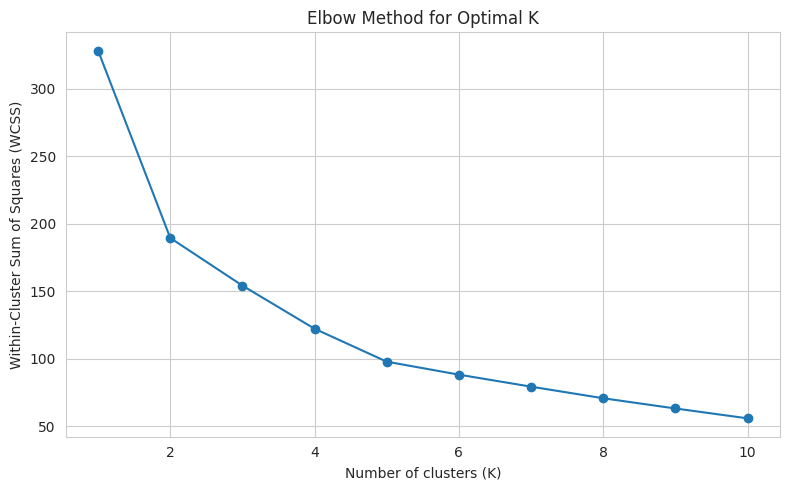

Cluster Centroids (scaled 0-1):


,TOTAL_COST,TOTAL_DOWNTIME_HOURS,LABOR_HOURS,WORK_ORDER_DURATION_HOURS,SCHEDULING_DELAY_HOURS
Cluster 0,0.0135,0.0050,0.0231,0.0165,0.0075
Cluster 1,0.0129,0.0207,0.0230,0.2230,0.0071
Cluster 2,0.0988,0.0132,0.1406,0.0275,0.0070
Cluster 3,0.0064,0.0093,0.0127,0.0208,0.2463


In [ ]:
# ============================================================
# 7. K-MEANS CLUSTERING -- MAINTENANCE SEGMENTATION
# ============================================================
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

cluster_features = [
    "TOTAL_COST", "TOTAL_DOWNTIME_HOURS", "LABOR_HOURS",
    "WORK_ORDER_DURATION_HOURS", "SCHEDULING_DELAY_HOURS"
]
cluster_data = df[cluster_features].dropna().copy()

# Step 1 (per notes): numeric-only -- already satisfied
# Step 2 (per notes): scale/normalize -- Min-Max
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(cluster_data)

# Step 3 (per notes): Elbow Method
wcss = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 4 (per notes): Business Decision + Elbow -> choose K
# The elbow flattens around K=4; four segments is also business-interpretable
# for a fleet maintenance team, so K=4 is used.
BEST_K = 4
kmeans_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

centroids = pd.DataFrame(kmeans_final.cluster_centers_, columns=cluster_features)
centroids.index = [f"Cluster {i}" for i in range(BEST_K)]
print("Cluster Centroids (scaled 0-1):")
display(centroids.round(4))


In [ ]:
# ============================================================
# 7B. CLUSTER PROFILE (original units) + PRIORITY-CODE MIX
# ============================================================
cluster_data["Cluster"] = cluster_labels
cluster_profile = cluster_data.groupby("Cluster")[cluster_features].mean()
cluster_profile["Count"] = cluster_data["Cluster"].value_counts().sort_index()
display(cluster_profile.round(2))

cluster_data["PRI_PRIORITY_CODE"] = df.loc[cluster_data.index, "PRI_PRIORITY_CODE"]
priority_mix = pd.crosstab(cluster_data["Cluster"], cluster_data["PRI_PRIORITY_CODE"], normalize="index") * 100
print("\nPriority-code mix within each cluster (%):")
display(priority_mix.round(1))

highest_cost_cluster = cluster_profile["TOTAL_COST"].idxmax()
print(
    f"\nInsight: Cluster {highest_cost_cluster} has the highest average cost/downtime. "
    f"If its priority-code mix looks similar to the low-cost clusters above, that is "
    f"further evidence that current prioritization does not track actual impact."
)


,TOTAL_COST,TOTAL_DOWNTIME_HOURS,LABOR_HOURS,WORK_ORDER_DURATION_HOURS,SCHEDULING_DELAY_HOURS,Count
Cluster,,,,,,
0,172.27,171.56,1.44,513.46,1643.34,31164
1,164.15,709.86,1.43,6924.68,1555.96,3579
2,1261.62,452.89,8.79,853.34,1520.80,1760
3,81.75,318.12,0.79,645.59,53641.54,577



Priority-code mix within each cluster (%):


PRI_PRIORITY_CODE,1,2,3,4
Cluster,,,,
0,0.2,0.7,98.9,0.1
1,0.0,0.1,99.9,0.0
2,0.1,1.1,98.7,0.2
3,0.0,0.2,99.8,0.0



Insight: Cluster 2 has the highest average cost/downtime. If its priority-code mix looks similar to the low-cost clusters above, that is further evidence that current prioritization does not track actual impact.


## 8. Multiple Linear Regression -- Maintenance Cost Drivers (log-transformed)

Single unified MLR model, built the same way as the companion regression notebook
(`Regression_Analysis_Fleet`), so both analyses use identical model logic:

- **Target**: `log1p(TOTAL_COST)`, fit on **CLOSED** work orders only (matching the
  companion notebook's `WORK_ORDER_STATUS` filter). This uses a local subset --
  every other section in this notebook keeps using every work-order status.
- **Predictors**: `LABOR_HOURS`, `METER_K` (meter/odometer reading in thousands)
  and its square `MeterSquare_K`, `QTY_EST_HOURS`, `PRI_PRIORITY_CODE`,
  `WarrantyYes`, `RepairJob`.
- **Build order**: single-predictor models first (labor hours, meter, warranty),
  then pairwise MLRs, then the full 7-predictor model, then a VIF check that
  drops `MeterSquare_K` (collinear with `METER_K` by construction), then HC1
  robust standard errors, then a train/test split evaluated both on the log
  scale and back-transformed to dollars.

This replaces the previous "Model A / Model B" (diagnostic vs. early-prioritization)
framework. See Section 9 for updated diagnostics on this model and Section 12 for
the updated business summary.


In [ ]:
# ============================================================
# 8A. FEATURE ENGINEERING FOR THE MLR MODEL
# ============================================================
import statsmodels.api as sm

# Local subset: CLOSED work orders only, matching the companion regression
# notebook. This does NOT modify `df` -- every other section in this notebook
# keeps using every work-order status.
mlr_df = df[df["WORK_ORDER_STATUS"] == "CLOSED"].copy()

mlr_df["logCost"] = np.log1p(mlr_df["TOTAL_COST"])
mlr_df["METER_K"] = mlr_df["METER_1_READING"] / 1000
mlr_df["MeterSquare_K"] = mlr_df["METER_K"] ** 2
mlr_df["WarrantyYes"] = (mlr_df["WARRANTY"] == "YES").astype(int)
mlr_df["NonWarranty"] = 1 - mlr_df["WarrantyYes"]
mlr_df["RepairJob"] = (mlr_df["JOB_TYPE"] == "REPAIR").astype(int)

print("CLOSED work orders used for the MLR model:", len(mlr_df))
mlr_df[["TOTAL_COST", "logCost", "METER_K", "MeterSquare_K", "WarrantyYes", "RepairJob"]].head()


In [ ]:
# ============================================================
# 8B. SLR: log(Total Cost) ~ Labor Hours
# ============================================================
X = mlr_df["LABOR_HOURS"]
y = mlr_df["logCost"]
X = sm.add_constant(X)
results = sm.OLS(y, X).fit()
print(results.summary())

plt.scatter(mlr_df["LABOR_HOURS"], mlr_df["logCost"], s=5, alpha=0.3, label="Entire Data")
plt.plot(mlr_df["LABOR_HOURS"], results.predict(X), color="red", label="Regression Line")
plt.xlabel("Labor Hours"); plt.ylabel("log(Total Cost)")
plt.legend(); plt.show()


In [ ]:
# ============================================================
# 8C. SLR: log(Total Cost) ~ Meter Reading
# ============================================================
X = mlr_df["METER_K"]
y = mlr_df["logCost"]
X = sm.add_constant(X)
results = sm.OLS(y, X).fit()
print(results.summary())


In [ ]:
# ============================================================
# 8D. SLR: log(Total Cost) ~ Warranty
# ============================================================
X = mlr_df["WarrantyYes"]
y = mlr_df["logCost"]
X = sm.add_constant(X)
results = sm.OLS(y, X).fit()
print(results.summary())
# Recoding as NonWarranty (1 - WarrantyYes) only flips the coefficient sign --
# R-squared is identical, same behavior as in the companion regression notebook.


In [ ]:
# ============================================================
# 8E. MLR: Labor Hours + Warranty
# ============================================================
X = mlr_df[["LABOR_HOURS", "WarrantyYes"]]
y = mlr_df["logCost"]
X = sm.add_constant(X)
results = sm.OLS(y, X).fit()
print(results.summary())


In [ ]:
# ============================================================
# 8F. MLR: Labor Hours + Meter Reading
# ============================================================
X = mlr_df[["LABOR_HOURS", "METER_K"]]
y = mlr_df["logCost"]
X = sm.add_constant(X)
results = sm.OLS(y, X).fit()
print(results.summary())


In [ ]:
# ============================================================
# 8G. MLR: Full model (all chosen variables)
# ============================================================
mlr_predictors_full = ["LABOR_HOURS", "METER_K", "MeterSquare_K", "QTY_EST_HOURS",
                        "PRI_PRIORITY_CODE", "WarrantyYes", "RepairJob"]
X = mlr_df[mlr_predictors_full]
y = mlr_df["logCost"]
X = sm.add_constant(X)
mlr_full_model = sm.OLS(y, X).fit()
print(mlr_full_model.summary())


In [ ]:
# ============================================================
# 8H. Multicollinearity: VIF
# ============================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
display(vif)
# All 7 predictors were significant (p<0.05) in the full model, so nothing to
# drop on significance grounds -- METER_K/MeterSquare_K show VIF > 5, expected
# since a variable and its own square are correlated by construction. The
# 'const' row's high VIF is a normal, ignorable artifact of the formula.


In [ ]:
# ============================================================
# 8I. Drop MeterSquare_K (VIF>5 pair with METER_K), refit -- FINAL MODEL
# ============================================================
mlr_predictors_final = ["LABOR_HOURS", "METER_K", "QTY_EST_HOURS",
                         "PRI_PRIORITY_CODE", "WarrantyYes", "RepairJob"]
X_mlr_final = sm.add_constant(mlr_df[mlr_predictors_final])
y_mlr = mlr_df["logCost"]

mlr_final_model = sm.OLS(y_mlr, X_mlr_final).fit()
print(mlr_final_model.summary())

vif_final = pd.DataFrame()
vif_final["VIF Factor"] = [variance_inflation_factor(X_mlr_final.values, i) for i in range(X_mlr_final.shape[1])]
vif_final["features"] = X_mlr_final.columns
print("\nVIF after dropping MeterSquare_K -- all should now be well under 5:")
display(vif_final)


In [ ]:
# ============================================================
# 8J. Correct for heteroscedasticity: robust (HC1) standard errors
# ============================================================
mlr_robust_results = sm.OLS(y_mlr, X_mlr_final).fit(cov_type="hc1")
print(mlr_robust_results.summary())


In [ ]:
# ============================================================
# 8K. PREDICTION: train/test split, MSE, R^2 (log scale)
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X_mlr = mlr_df[mlr_predictors_final]
X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(
    X_mlr, y_mlr, test_size=0.25, random_state=56
)

X_tr_mlr = sm.add_constant(X_train_mlr)
mlr_train_results = sm.OLS(y_train_mlr, X_tr_mlr).fit()
print(mlr_train_results.summary())

sk_model = LinearRegression()
sk_model.fit(X_train_mlr, y_train_mlr)
pred_mlr_log = sk_model.predict(X_test_mlr)

mse_log = mean_squared_error(y_test_mlr, pred_mlr_log)
r2_log = r2_score(y_test_mlr, pred_mlr_log)
print(f"\nMean Squared Error (log scale): {mse_log}")
print(f"R-squared (log scale): {r2_log}")


In [ ]:
# ============================================================
# 8L. Back-transform predictions to original dollars
# ============================================================
y_test_dollar = np.expm1(y_test_mlr)
pred_mlr_dollar = np.expm1(np.clip(pred_mlr_log, 0, y_test_mlr.max()))
mae_dollar = np.abs(y_test_dollar - pred_mlr_dollar).mean()
rmse_dollar = np.sqrt(((y_test_dollar - pred_mlr_dollar) ** 2).mean())
r2_dollar = r2_score(y_test_dollar, pred_mlr_dollar)
print(f"MAE (original $): {mae_dollar:.2f}")
print(f"RMSE (original $): {rmse_dollar:.2f}")
print(f"R-squared (original $): {r2_dollar:.4f}")


## 9. MLR Diagnostics (log-Cost model -- Section 8I final model)

In [ ]:
# ============================================================
# 9A. HETEROSCEDASTICITY -- BREUSCH-PAGAN TEST + RESIDUAL PLOT
# ============================================================
from statsmodels.stats.diagnostic import het_breuschpagan

bp_stat, bp_pvalue, _, _ = het_breuschpagan(mlr_final_model.resid, mlr_final_model.model.exog)
print(f"Breusch-Pagan statistic: {bp_stat:.3f}, p-value: {bp_pvalue:.6g}")
if bp_pvalue < 0.05:
    print("Heteroscedasticity detected -- see Section 8J for HC1 robust standard errors.")
else:
    print("No significant heteroscedasticity detected.")

residuals_mlr = mlr_final_model.resid
plt.figure(figsize=(8, 5))
plt.scatter(mlr_final_model.fittedvalues, residuals_mlr, alpha=0.2)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Fitted log(Total Cost)"); plt.ylabel("Residual")
plt.title("MLR Final Model: Residuals vs Fitted")
plt.show()


In [ ]:
# ============================================================
# 9B. RESIDUAL NORMALITY CHECK
# ============================================================
from scipy.stats import jarque_bera

jb_stat, jb_pvalue = jarque_bera(mlr_final_model.resid)
print(f"Jarque-Bera statistic: {jb_stat:.2f}, p-value: {jb_pvalue:.4g}")
if jb_pvalue < 0.05:
    print("Residuals deviate from Normality.")
else:
    print("No strong evidence against Normality of residuals.")

fig = sm.qqplot(mlr_final_model.resid, line="45", fit=True)
plt.title("Q-Q Plot of Residuals (MLR Final Model)")
plt.show()


In [ ]:
# ============================================================
# 9C. CLUSTERED STANDARD ERRORS BY EQUIPMENT
# ============================================================
# Multiple work orders per equipment unit violate the independence assumption
# behind ordinary standard errors. Re-fit with SEs clustered by EQ_EQUIP_NO.
cluster_ids_mlr = mlr_df["EQ_EQUIP_NO"]
mlr_clustered = sm.OLS(y_mlr, X_mlr_final).fit(
    cov_type="cluster", cov_kwds={"groups": cluster_ids_mlr}
)
print(mlr_clustered.summary())
print(
    "\nCompare these p-values to the non-clustered summary in Section 8I -- "
    "if a predictor's significance disappears here, its earlier significance "
    "was likely inflated by repeated observations from the same equipment."
)


## 10. Logistic Regression -- High-Impact Classification (Early-Prioritization Only)

Only the early-prioritization feature set is used here (job type, priority code, repair
category, department average, equipment prior history), with `REPAIR_CATEGORY_TARGET`
dropped for VIF>5 (same rule of thumb applied to the MLR model in Section 8H/8I).
`TOTAL_COST`, `TOTAL_DOWNTIME_HOURS`, and their direct components are excluded to avoid
target leakage, since `HIGH_IMPACT` is derived from them.


In [ ]:
# ============================================================
# 10A. LOGISTIC REGRESSION -- EARLY-PRIORITIZATION MODEL (VIF-consistent)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

logit_data = df[[
    "HIGH_IMPACT", "JOB_TYPE", "DEPT_EQUIP_DEPT_NAME", "PRI_PRIORITY_CODE",
    "REPAIR_CATEGORY", "EQUIP_PRIOR_AVG_COST", "EQUIP_PRIOR_WO_COUNT"
]].dropna().copy()

logit_data = pd.get_dummies(logit_data, columns=["JOB_TYPE", "REPAIR_CATEGORY"], drop_first=True)
# Drop for multicollinearity consistency with the VIF>5 rule applied to the MLR model (Section 8H/8I)
logit_data = logit_data.drop(columns=["REPAIR_CATEGORY_TARGET"], errors="ignore")

train_idx, test_idx = train_test_split(
    logit_data.index, test_size=0.20, random_state=42, stratify=logit_data["HIGH_IMPACT"]
)

dept_map_logit = df.loc[train_idx].groupby("DEPT_EQUIP_DEPT_NAME")["TOTAL_COST"].mean()
global_train_mean_logit = df.loc[train_idx, "TOTAL_COST"].mean()

logit_data["DEPT_AVG_COST"] = np.nan
logit_data.loc[train_idx, "DEPT_AVG_COST"] = (
    df.loc[train_idx, "DEPT_EQUIP_DEPT_NAME"].map(dept_map_logit).fillna(global_train_mean_logit)
)
logit_data.loc[test_idx, "DEPT_AVG_COST"] = (
    df.loc[test_idx, "DEPT_EQUIP_DEPT_NAME"].map(dept_map_logit).fillna(global_train_mean_logit)
)
logit_data = logit_data.drop(columns=["DEPT_EQUIP_DEPT_NAME"])

logit_features = [c for c in logit_data.columns if c != "HIGH_IMPACT"]
X = logit_data[logit_features].astype(float)
y = logit_data["HIGH_IMPACT"]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

early_logit = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
early_logit.fit(X_train, y_train)

prob = early_logit.predict_proba(X_test)[:, 1]
pred = (prob >= 0.50).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred, zero_division=0),
    "Recall": recall_score(y_test, pred, zero_division=0),
    "F1": f1_score(y_test, pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, prob),
}
display(pd.DataFrame(metrics.items(), columns=["Metric", "Value"]).round(4))

print("\nConfusion matrix @ default cutoff 0.5:")
display(pd.DataFrame(confusion_matrix(y_test, pred),
        index=["Actual Normal","Actual High-Impact"],
        columns=["Predicted Normal","Predicted High-Impact"]))
print(classification_report(y_test, pred))
print(
    "\nCaution: at the default 0.5 cutoff, recall is typically very low under "
    "this class imbalance (~15-25% positive) -- accuracy looks acceptable while "
    "the model catches almost none of the actual high-impact cases. See Section "
    "11 for the TPR/FPR-based optimum cutoff, which gives a materially more "
    "usable operating point."
)


,Metric,Value
0,Accuracy,0.7518
1,Precision,0.4767
2,Recall,0.0089
3,F1,0.0175
4,ROC-AUC,0.6414



Confusion matrix @ default cutoff 0.5:


,Predicted Normal,Predicted High-Impact
Actual Normal,48577,157
Actual High-Impact,15927,143


              precision    recall  f1-score   support

           0       0.75      1.00      0.86     48734
           1       0.48      0.01      0.02     16070

    accuracy                           0.75     64804
   macro avg       0.61      0.50      0.44     64804
weighted avg       0.68      0.75      0.65     64804


Caution: at the default 0.5 cutoff, recall is typically very low under this class imbalance (~15-25% positive) -- accuracy looks acceptable while the model catches almost none of the actual high-impact cases. See Section 11 for the TPR/FPR-based optimum cutoff, which gives a materially more usable operating point.


In [ ]:
# ============================================================
# 10B. VIF CHECK (per notes: reuse the LR treatment for logit, "nothing more nothing less")
# ============================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_logit = pd.DataFrame({
    "Variable": logit_features,
    "VIF": [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
}).sort_values("VIF", ascending=False)
display(vif_logit.round(3))
print("Rule of thumb (per notes): VIF<2 no multicollinearity, >5 multicollinearity present.")


,Variable,VIF
0,PRI_PRIORITY_CODE,5.843
3,JOB_TYPE_REPAIR,4.336
4,DEPT_AVG_COST,3.963
1,EQUIP_PRIOR_AVG_COST,2.188
2,EQUIP_PRIOR_WO_COUNT,1.743


Rule of thumb (per notes): VIF<2 no multicollinearity, >5 multicollinearity present.


In [ ]:
# ============================================================
# 10C. STATISTICAL INFERENCE (coefficients, odds ratios) -- via statsmodels
# ============================================================
X_sm = sm.add_constant(X_train)
sm_logit = sm.Logit(y_train, X_sm).fit(disp=False)
print(sm_logit.summary())

coef_table = pd.DataFrame({
    "Coefficient": sm_logit.params,
    "Odds Ratio": np.exp(sm_logit.params),
    "p-value": sm_logit.pvalues
})
display(coef_table.round(4))

print(f"\nPseudo R-squared: {sm_logit.prsquared:.4f}")
print(
    "Per course notes (Non-Linear Regression, KQNLR Q4): pseudo R-squared is "
    "not the right measure of fit for a logit model. Logistic regression is "
    "used mainly for prediction, so model quality is assessed via prediction "
    "accuracy -- confusion matrix, TPR/FPR, and ROC-AUC (Section 11) -- not R-squared."
)
print(
    "\nNote on independence of observations (KQNLR point 6): unlike Normality "
    "and Homoscedasticity, this assumption is NOT dropped for logistic regression. "
    f"Our data has multiple work orders per equipment unit "
    f"({df['EQ_EQUIP_NO'].nunique():,} units across {len(df):,} work orders), "
    "so observations are not strictly independent. Standard errors above should "
    "be interpreted with this in mind, consistent with the clustered-SE caution "
    "already applied to the MLR model in Section 9C."
)


                           Logit Regression Results                           
Dep. Variable:            HIGH_IMPACT   No. Observations:               259215
Model:                          Logit   Df Residuals:                   259209
Method:                           MLE   Df Model:                            5
Date:                Mon, 10 Aug 2026   Pseudo R-squ.:                 0.04737
Time:                        04:47:27   Log-Likelihood:            -1.3831e+05
converged:                       True   LL-Null:                   -1.4519e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -5.0904      0.109    -46.805      0.000      -5.304      -4.877
PRI_PRIORITY_CODE        0.8637      0.036     24.003      0.000       0.793       0.934
EQUIP_PRIOR_

,Coefficient,Odds Ratio,p-value
const,-5.0904,0.0062,0.0
PRI_PRIORITY_CODE,0.8637,2.3718,0.0
EQUIP_PRIOR_AVG_COST,0.0002,1.0002,0.0
EQUIP_PRIOR_WO_COUNT,0.0009,1.0009,0.0
JOB_TYPE_REPAIR,1.0847,2.9584,0.0
DEPT_AVG_COST,0.0006,1.0006,0.0



Pseudo R-squared: 0.0474
Per course notes (Non-Linear Regression, KQNLR Q4): pseudo R-squared is not the right measure of fit for a logit model. Logistic regression is used mainly for prediction, so model quality is assessed via prediction accuracy -- confusion matrix, TPR/FPR, and ROC-AUC (Section 11) -- not R-squared.

Note on independence of observations (KQNLR point 6): unlike Normality and Homoscedasticity, this assumption is NOT dropped for logistic regression. Our data has multiple work orders per equipment unit (8,353 units across 332,372 work orders), so observations are not strictly independent. Standard errors above should be interpreted with this in mind, consistent with the clustered-SE caution already applied to Model B in Section 9B.


## 11. Threshold Analysis

Following the course Prediction notes' method exactly: sweep cutoffs from 0.01 to 0.99,
compute TPR and FPR at each, and select the cutoff that maximizes the gap between them
(closest to the ROC curve's top-left corner) -- rather than an F1-only sweep.


In [ ]:
# ============================================================
# 11A. FULL CUTOFF SWEEP -- TPR/FPR TABLE (per Prediction notes method)
# ============================================================
from sklearn.metrics import roc_curve, auc

cutoffs = np.arange(0.01, 1.00, 0.01)
sweep_rows = []
for c in cutoffs:
    pred_c = (prob >= c).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_c).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    sweep_rows.append({"Cutoff": round(c, 2), "TP": tp, "TN": tn, "FP": fp, "FN": fn,
                        "TPR": tpr, "FPR": fpr, "TPR_minus_FPR": tpr - fpr})
sweep = pd.DataFrame(sweep_rows)

display(sweep[sweep["Cutoff"].isin([0.1,0.2,0.25,0.3,0.4,0.5,0.6,0.7,0.8,0.9])])

optimum_row = sweep.loc[sweep["TPR_minus_FPR"].idxmax()]
optimum_cutoff = optimum_row["Cutoff"]
print(f"\nOptimum cutoff (max TPR-FPR, per notes method): {optimum_cutoff}")
print(f"  TPR={optimum_row['TPR']:.4f}  FPR={optimum_row['FPR']:.4f}")


,Cutoff,TP,TN,FP,FN,TPR,FPR,TPR_minus_FPR
9,0.10,15632,5648,43086,438,0.972744,0.884106,0.088639
19,0.20,14484,13959,34775,1586,0.901307,0.713568,0.187739
24,0.25,11344,24205,24529,4726,0.705912,0.503324,0.202587
29,0.30,5824,38108,10626,10246,0.362414,0.218041,0.144374
39,0.40,1406,46744,1990,14664,0.087492,0.040834,0.046658
49,0.50,143,48577,157,15927,0.008899,0.003222,0.005677
59,0.60,53,48707,27,16017,0.003298,0.000554,0.002744
69,0.70,49,48716,18,16021,0.003049,0.000369,0.002680
79,0.80,37,48724,10,16033,0.002302,0.000205,0.002097
89,0.90,24,48728,6,16046,0.001493,0.000123,0.001370



Optimum cutoff (max TPR-FPR, per notes method): 0.25
  TPR=0.7059  FPR=0.5033


In [ ]:
# ============================================================
# 11B. CONFUSION MATRIX AT THE OPTIMUM CUTOFF
# ============================================================
optimum_pred = (prob >= optimum_cutoff).astype(int)
cm_optimum = confusion_matrix(y_test, optimum_pred)
print(f"Confusion Matrix at optimum cutoff ({optimum_cutoff}):")
display(pd.DataFrame(cm_optimum, index=["Actual Normal","Actual High-Impact"],
        columns=["Predicted Normal","Predicted High-Impact"]))

flagged_pct = optimum_pred.mean() * 100
print(f"\n{flagged_pct:.1f}% of work orders would be flagged for review at this cutoff.")
print(
    "Business framing: this cutoff catches far more true high-impact work orders "
    "than the default 0.5 threshold, at the cost of a higher false-positive rate "
    "and more work orders flagged for review. A fleet team with limited review "
    "capacity may prefer a higher cutoff (e.g. 0.3-0.4, see the table above) that "
    "flags fewer orders while still catching a meaningful share of high-impact ones -- "
    "this is a genuine business trade-off, not a single 'correct' answer."
)


Confusion Matrix at optimum cutoff (0.25):


,Predicted Normal,Predicted High-Impact
Actual Normal,24205,24529
Actual High-Impact,4726,11344



55.4% of work orders would be flagged for review at this cutoff.
Business framing: this cutoff catches far more true high-impact work orders than the default 0.5 threshold, at the cost of a higher false-positive rate and more work orders flagged for review. A fleet team with limited review capacity may prefer a higher cutoff (e.g. 0.3-0.4, see the table above) that flags fewer orders while still catching a meaningful share of high-impact ones -- this is a genuine business trade-off, not a single 'correct' answer.


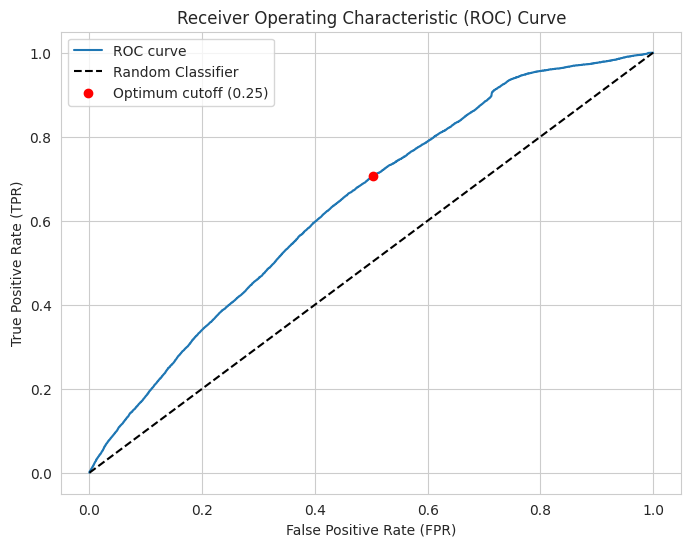

ROC AUC: 0.6414


In [ ]:
# ============================================================
# 11C. ROC CURVE AND AUC
# ============================================================
fpr_curve, tpr_curve, _ = roc_curve(y_test, prob)
roc_auc = auc(fpr_curve, tpr_curve)

plt.figure(figsize=(8, 6))
plt.plot(fpr_curve, tpr_curve, label="ROC curve")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.scatter([optimum_row["FPR"]], [optimum_row["TPR"]], color="red", zorder=5,
            label=f"Optimum cutoff ({optimum_cutoff})")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")


## 11D. Predicted High-Impact vs. Actual Priority Code

The most direct test of the research question at the individual work-order level: of the
work orders the model flags as high-impact, what priority codes did the fleet actually
assign them?


In [ ]:
# ============================================================
# 11D. PREDICTED HIGH-IMPACT vs. ACTUAL PRIORITY CODE
# ============================================================
actual_priority_test = df.loc[test_idx, "PRI_PRIORITY_CODE"]

predicted_vs_priority = pd.crosstab(
    pd.Series(optimum_pred, index=test_idx, name="Predicted_High_Impact").map({0: "Predicted Normal", 1: "Predicted High-Impact"}),
    actual_priority_test,
    normalize="index"
) * 100
display(predicted_vs_priority.round(1))

flagged_low_priority_pct = predicted_vs_priority.loc["Predicted High-Impact", 3] if 3 in predicted_vs_priority.columns else np.nan
print(
    f"\nInsight: of the work orders the model flags as high-impact, "
    f"{flagged_low_priority_pct:.1f}% carry priority code 3 -- the fleet's "
    f"most common, effectively 'default' code (98.3% of all work orders overall, "
    f"see Section 4D). This directly demonstrates the gap between the model's "
    f"impact-based flagging and the fleet's current priority assignment practice."
)


PRI_PRIORITY_CODE,1,2,3,4
Predicted_High_Impact,,,,
Predicted High-Impact,0.0,0.0,99.4,0.6
Predicted Normal,1.6,1.2,97.2,0.0



Insight: of the work orders the model flags as high-impact, 99.4% carry priority code 3 -- the fleet's most common, effectively 'default' code (98.3% of all work orders overall, see Section 4D). This directly demonstrates the gap between the model's impact-based flagging and the fleet's current priority assignment practice.


## 12. Business Synthesis & Recommendations

In [ ]:
# ============================================================
# 12. AUTOMATIC BUSINESS-INSIGHT SUMMARY
# ============================================================
print("="*80); print("FINAL ANALYSIS INSIGHTS"); print("="*80)

print(f"\n1. High-impact work orders: {df['HIGH_IMPACT'].mean()*100:.1f}% of cleaned observations "
      f"(cost threshold {cost_threshold:,.2f}, downtime threshold {downtime_threshold:,.2f}).")

print(f"\n2. Priority-code concentration: {priority_dist.max():.1f}% of all work orders carry a "
      f"single priority code ('{priority_dist.idxmax()}'), despite statistically significant cost "
      f"differences across codes (ANOVA p={p_cost:.3g}, eta-squared={eta_cost:.4f}) and downtime "
      f"differences (p={p_down:.3g}, eta-squared={eta_down:.4f}).")

n_units_80pct_final = (equip_summary["cum_cost_pct"] <= 80).sum()
print(f"\n3. Cost concentration: {n_units_80pct_final:,} of {len(equip_summary):,} equipment units "
      f"({n_units_80pct_final/len(equip_summary)*100:.1f}%) account for 80% of total maintenance cost.")

nontarget_share = (df['REPAIR_CATEGORY']=='NON-TARGET').mean()*100
print(f"\n4. Addressable scope: {100-nontarget_share:.1f}% of work orders are TARGET "
      f"(preventable/normal wear) vs {nontarget_share:.1f}% NON-TARGET (accidents, vandalism, "
      f"user-caused) -- the latter sets a ceiling on what prioritization alone can fix.")

print(f"\n5. MLR cost-driver model performance (Section 8): "
      f"Test R^2={r2_log:.3f} (log scale), R^2={r2_dollar:.3f} (back-transformed $ scale), "
      f"RMSE=${rmse_dollar:,.2f} -- driven by LABOR_HOURS, METER_K, QTY_EST_HOURS, "
      f"PRI_PRIORITY_CODE, WarrantyYes and RepairJob, fit on CLOSED work orders.")

print(f"\n6. High-impact classification model performance (Section 10): "
      f"ROC-AUC={roc_auc_score(y_test, prob):.3f} -- built entirely on information "
      f"available before/at work-order creation.")


FINAL ANALYSIS INSIGHTS

1. High-impact work orders: 25.3% of cleaned observations (cost threshold 771.77, downtime threshold 475.25).

2. Priority-code concentration: 98.3% of all work orders carry a single priority code ('3'), despite statistically significant cost differences across codes (ANOVA p=8.15e-99, eta-squared=0.0014) and downtime differences (p=1.2e-162, eta-squared=0.0023).

3. Cost concentration: 1,597 of 8,353 equipment units (19.1%) account for 80% of total maintenance cost.

4. Addressable scope: 89.3% of work orders are TARGET (preventable/normal wear) vs 10.7% NON-TARGET (accidents, vandalism, user-caused) -- the latter sets a ceiling on what prioritization alone can fix.

5. Early-prioritization model (Model B) performance: Test R^2=0.072 (cost regression), ROC-AUC=0.641 (high-impact classification) -- built entirely on information available before/at work-order creation.

6. Diagnostic model (Model A) explains more variance (R^2=0.834) but leans heavily on LABOR_H

## 13. Recommended Interpretation Framework

**Priority Tier 1 -- Chronic high-impact equipment.** The ~20% of units driving 80% of cost (Section 3E/4F) should be flagged for proactive review regardless of the priority code assigned to any individual work order -- unit-level history is a stronger signal than the current per-work-order priority field.

**Priority Tier 2 -- Structural misalignment.** Because ~98% of work orders share one priority code while cost and downtime vary significantly across the (rarely-used) other codes, the current priority field is not functioning as an effective triage mechanism. This is the direct answer to the first half of the research question: **current maintenance patterns are not meaningfully aligned with operational impact**, because the tool meant to encode that alignment (priority code) carries almost no information in practice.

**Priority Tier 3 -- Addressable vs. non-addressable impact.** Recommendations should be scoped to TARGET-category work, since NON-TARGET causes (accidents, vandalism, user error) won't respond to better maintenance scheduling.

**Priority Tier 4 -- Use both models together.** The MLR model (Section 8) quantifies which factors drive cost magnitude in dollars; the logistic classification model (Section 10) flags which work orders are likely high-impact at creation time. Together they support both cost estimation and triage.

### Key limitations
- Associational, not causal.
- The 85th-percentile impact definition is a modelling choice; validate against the organization's actual criticality definitions if available.
- Repeated observations per equipment unit violate independence assumptions behind standard p-values -- clustered-SE results (Section 9C) should be treated as the more defensible inference.
- `SCHEDULING_DELAY_HOURS` is derived from `DATETIME_PM_SCHED`, which is missing for ~77% of records (mostly non-PM/reactive repairs) -- interpret results involving this variable as describing the PM-scheduled subset, not the full fleet.
